In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv(r'/content/RegData.csv')

In [ ]:
data.describe()

,StID,SAT,GPA
count,84.000000,84.000000,84.000000
mean,149.619048,1345.273810,3.330238
std,29.499808,104.530661,0.271617
min,101.000000,1134.000000,2.400000
25%,122.750000,1272.000000,3.190000
50%,149.500000,1346.000000,3.380000
75%,175.500000,1434.000000,3.502500
max,198.000000,1550.000000,3.810000


In [ ]:
y = data['GPA']
x = data['SAT']

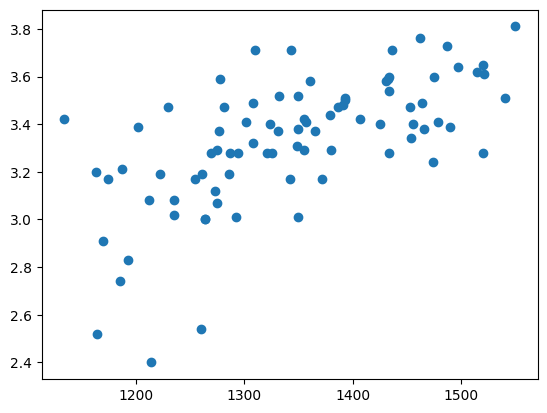

In [ ]:
plt.scatter(x,y)

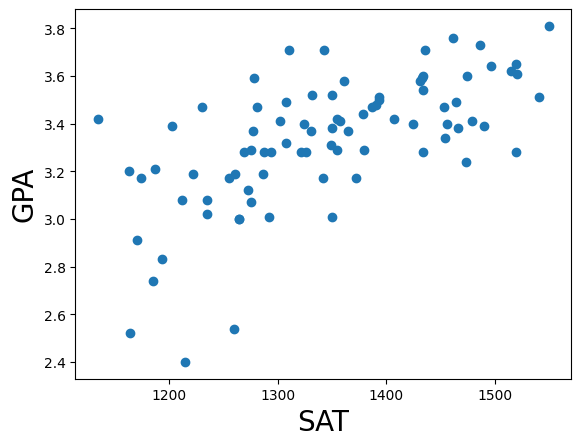

In [ ]:
plt.scatter(x,y)
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

In [ ]:
data[['SAT','GPA']].corr()

,SAT,GPA
SAT,1.000000,0.637184
GPA,0.637184,1.000000


In [ ]:
import seaborn as sns

<Axes: >

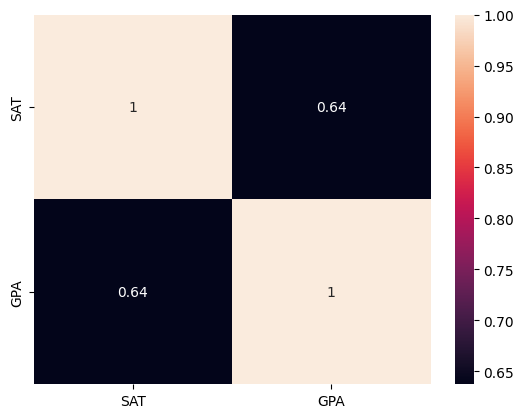

In [ ]:
sns.heatmap(data[['SAT','GPA']].corr(),annot = True)

In [ ]:
from scipy.stats import linregress

In [ ]:
slope, intercept, r_value, p_value, std_err = linregress(x,y)

In [ ]:
print("Slope:", slope)

Slope: 0.001655688050092813


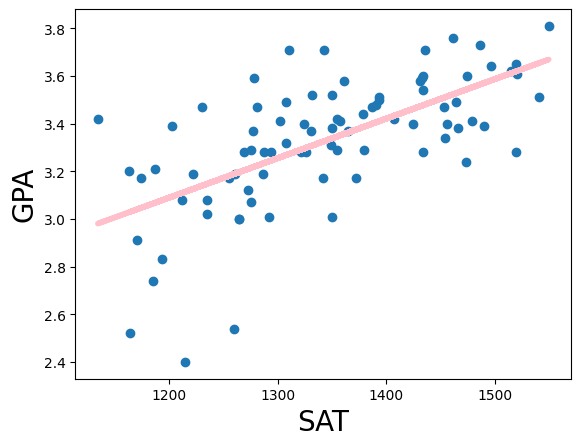

In [ ]:
plt.scatter(x, y)

y1 = slope*x + intercept

fig = plt.plot(x, y1, lw=4, c='pink', label='regression line')

plt.xlabel('SAT', fontsize=20)
plt.ylabel('GPA', fontsize=20)
plt.show()

In [ ]:
y1 = data['GPA']
x1 = data['SAT']

In [ ]:
slope, intercept, r_value, p_value, std_err = linregress(x1, y1)

In [ ]:
y2 = slope*x1 + intercept

Text(0, 0.5, 'GPA')

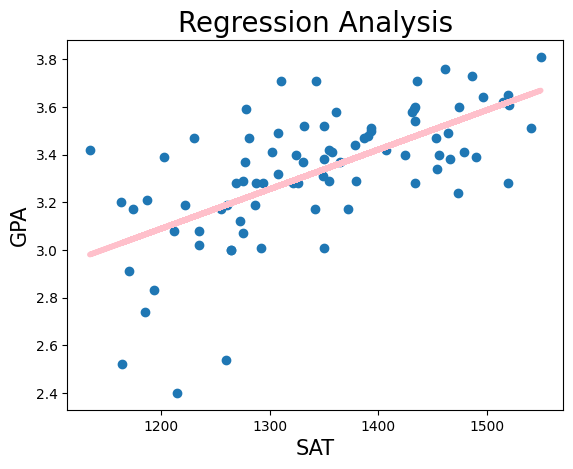

In [ ]:
fig = plt.figure
plt.scatter(x1,y1)

fig = plt.plot(x1,y2, lw=4, c='pink')

plt.title("Regression Analysis", fontsize = 20)
plt.xlabel('SAT', fontsize = 15)
plt.ylabel('GPA', fontsize = 15)


In [ ]:
## using y2 = slope*x1 + intercept

In [ ]:
givenSAT= 1450
predGPA = slope* givenSAT + intercept
predGPA

np.float64(3.503631997341267)

In [ ]:
df_p = pd.DataFrame({"ActualGPA":y1,"Predicted":y2})
df_p.head()

,ActualGPA,Predicted
0,3.42,3.346342
1,3.48,3.405946
2,2.91,3.040039
3,3.41,3.349653
4,3.28,3.298327


<Axes: >

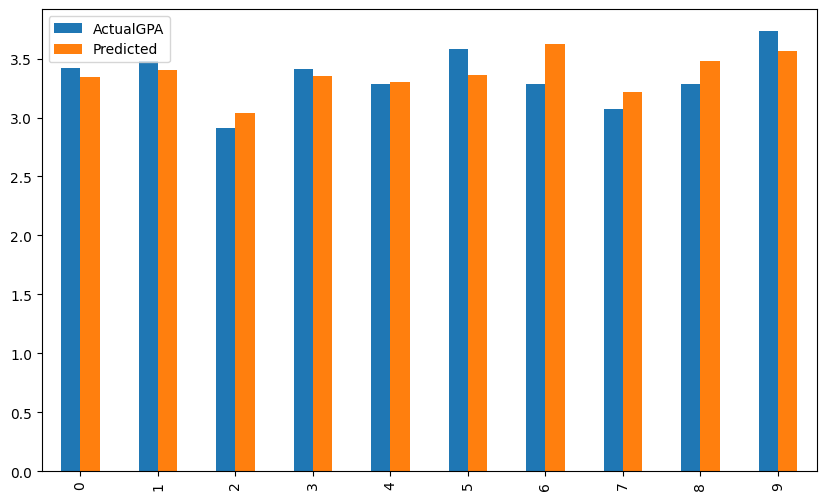

In [ ]:
df_p.head(10).plot(kind="bar",figsize=(10,6))

In [ ]:
df_a_p = pd.DataFrame({**data, "PredictedGPA":y2})
df_a_p.head()

,StID,SAT,GPA,PredictedGPA
0,101,1355,3.42,3.346342
1,102,1391,3.48,3.405946
2,103,1170,2.91,3.040039
3,104,1357,3.41,3.349653
4,105,1326,3.28,3.298327


In [ ]:
import seaborn as sns

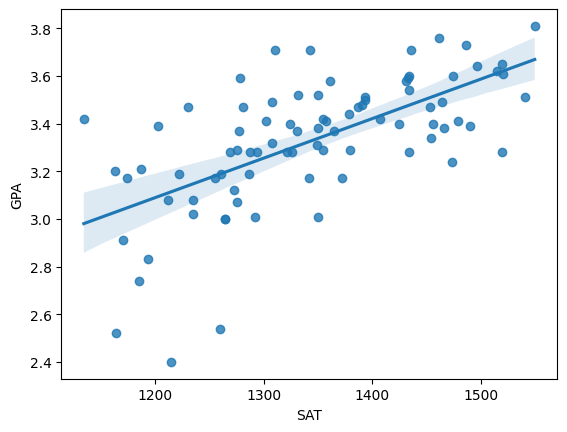

In [ ]:
p = sns.regplot(data=data, x=data.SAT, y=data.GPA)

<Axes: xlabel='SAT', ylabel='GPA'>

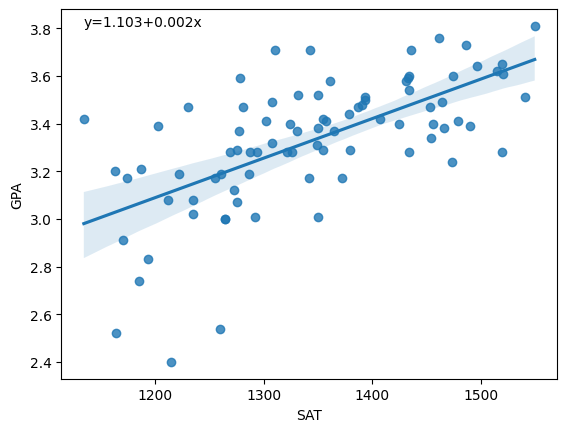

In [ ]:
plt.text(min(data.SAT),max(data.GPA),'y=' + str(round(intercept,3)) + '+' + str(round(slope,3)) + 'x')
sns.regplot(data=data,x=data.SAT,y=data.GPA)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = data.SAT
y = data.GPA

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3 , random_state=1)

X_train = X_train.to_numpy().reshape(-1,1)
X_test = X_test.to_numpy().reshape(-1,1)


In [ ]:
from sklearn.linear_model import LinearRegression
rgsr = LinearRegression()


In [ ]:
model= rgsr.fit(X_train,y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y = pd.DataFrame({'Original': y_test, 'Predicted': y_pred})
y.head()

,Original,Predicted
10,3.01,3.270437
67,3.40,3.527507
59,2.52,3.069796
33,3.71,3.298652
83,3.44,3.406809


<Axes: >

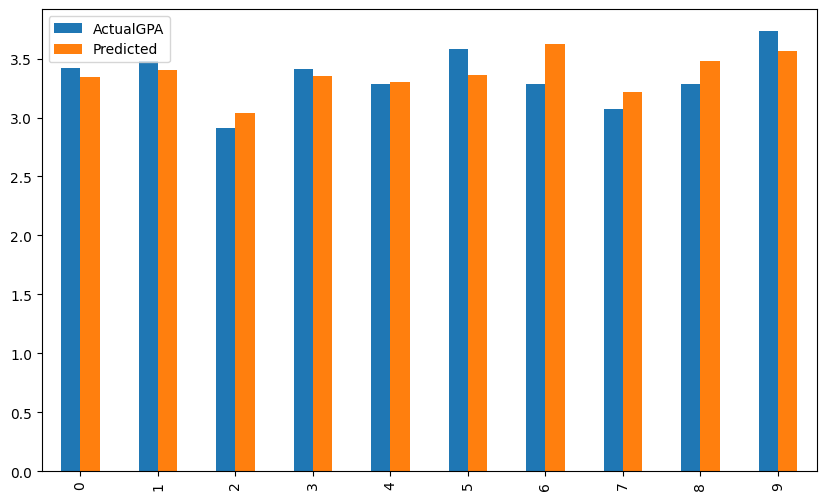

In [ ]:
df_p.head(10).plot(kind="bar",figsize=(10,6))

In [ ]:
from sklearn import metrics

In [ ]:
print('Evaluation indicators')
print("MAE: \t" , metrics.mean_absolute_error(y_test,y_pred))
print("MSE: \t" , metrics.mean_squared_error(y_test,y_pred))
print("RMSE: \t",  metrics.mean_squared_error(y_test,y_pred)**(0.5))
print("R-Squared:", metrics.r2_score(y_test,y_pred))

Evaluation indicators
MAE: 	 0.2054834292112158
MSE: 	 0.08052728657188303
RMSE: 	 0.28377330137256224
R-Squared: 0.3346446677333793


In [ ]:
import numpy as np

In [ ]:
b0 = 0.0
b1 = 0.0
learning_rate = 0.0000001
epochs = 1000
n = float(len(X_train))

In [ ]:
x_vals = X_train.flatten()
y_vals = y_train.to_numpy()

In [ ]:
for i in range(epochs):

    y_current = b1 * x_vals + b0

    D_b1 = (-2/n) * sum(x_vals * (y_vals - y_current))
    D_b0 = (-2/n) * sum(y_vals - y_current)

    b1 = b1 - learning_rate * D_b1
    b0 = b0 - learning_rate * D_b0

print(f"Final intercept (b0): {b0}")
print(f"Final slope (b1): {b1}")

Final intercept (b0): 3.0909328257626908e-06
Final slope (b1): 0.002489613858182571


In [ ]:
y_pred_gd = b1 * X_test.flatten() + b0

In [ ]:
from sklearn import metrics

print('---Gradient Descent Evaluation ---')
print("MAE: \t" , metrics.mean_absolute_error(y_test,y_pred_gd))
print("MSE: \t" , metrics.mean_squared_error(y_test,y_pred_gd))
print("RMSE: \t",  np.sqrt(metrics.mean_squared_error(y_test,y_pred_gd)))
print("R-squared:", metrics.r2_score(y_test,y_pred_gd))


---Gradient Descent Evaluation ---
MAE: 	 0.231072026745874
MSE: 	 0.0865375579259598
RMSE: 	 0.29417266685734045
R-squared: 0.2849849031486804
